In [ ]:
import pandas as pd
df=pd.read_csv("/content/Crop_recommendation.csv")
df

,temperature,humidity,ph,water availability,season,label
0,20.879744,82.002744,6.502985,202.935536,rainy,rice
1,21.770462,80.319644,7.038096,226.655537,rainy,rice
2,23.004459,82.320763,7.840207,263.964248,rainy,rice
3,26.491096,80.158363,6.980401,242.864034,rainy,rice
4,20.130175,81.604873,7.628473,262.717340,rainy,rice
...,...,...,...,...,...,...
1395,23.874845,86.792613,6.718725,177.514731,rainy,jute
1396,23.928879,88.071123,6.880205,154.660874,rainy,jute
1397,24.814412,81.686889,6.861069,190.788639,rainy,jute
1398,24.447439,82.286484,6.769346,190.968489,rainy,jute


In [ ]:
df.isna().sum()

,0
temperature,0
humidity,0
ph,0
water availability,0
season,0
label,0


In [ ]:
df.dtypes

,0
temperature,float64
humidity,float64
ph,float64
water availability,float64
season,object
label,object


# LABEL ENCODING

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
cols=['season','label']
for col in cols:
  df[col]=encoder.fit_transform(df[col])

In [ ]:
df.dtypes

,0
temperature,float64
humidity,float64
ph,float64
water availability,float64
season,int64
label,int64


In [ ]:
df['label'].value_counts()

,count
label,
6,200
11,100
1,100
4,100
10,100
7,100
8,100
0,100
5,100


# INPUT SPLITTING

In [ ]:
X=df.iloc[:,:-1]
X

,temperature,humidity,ph,water availability,season
0,20.879744,82.002744,6.502985,202.935536,0
1,21.770462,80.319644,7.038096,226.655537,0
2,23.004459,82.320763,7.840207,263.964248,0
3,26.491096,80.158363,6.980401,242.864034,0
4,20.130175,81.604873,7.628473,262.717340,0
...,...,...,...,...,...
1395,23.874845,86.792613,6.718725,177.514731,0
1396,23.928879,88.071123,6.880205,154.660874,0
1397,24.814412,81.686889,6.861069,190.788639,0
1398,24.447439,82.286484,6.769346,190.968489,0


# OUTPUT SPLITTING

In [ ]:
y=df.iloc[:,-1]
y

,label
0,11
1,11
2,11
3,11
4,11
...,...
1395,3
1396,3
1397,3
1398,3


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay





# SCALING

In [ ]:
scaler=MinMaxScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[0.2563489 , 0.83942036, 0.46626364, 0.65645778, 0.        ],
       [0.29749533, 0.81856518, 0.54948026, 0.74167459, 0.        ],
       [0.35449944, 0.84336091, 0.67421877, 0.87571039, 0.        ],
       ...,
       [0.43810964, 0.83550662, 0.52195026, 0.61281867, 0.        ],
       [0.42115744, 0.84293617, 0.50768606, 0.6134648 , 0.        ],
       [0.51940323, 0.73802786, 0.58423496, 0.49977228, 0.        ]])

# TRAINING

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=1)

In [ ]:
X_train.shape,y_train.shape

((980, 5), (980,))

In [ ]:
X_test.shape,y_test.shape

((420, 5), (420,))

In [ ]:
import warnings
warnings.filterwarnings('ignore')
models = {
    "GradientBoostingClassifier": GradientBoostingClassifier(),
    "AdaBoostClassifier": AdaBoostClassifier(learning_rate=5.0, random_state=1),
    "XGBClassifier": XGBClassifier(),
    "KNeighborsClassifier": KNeighborsClassifier(n_neighbors=3),
    "RandomForestClassifier": RandomForestClassifier(),
    "SVC": SVC(probability=True),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "GaussianNB": GaussianNB()
}

# Dictionary to store metrics
metrics = {}



for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    metrics[name] = report
    y_pred_prob = model.predict_proba(X_test)[:, 1]


    print(f"{name}\n{classification_report(y_test, y_pred)}\n{'_'*100}")




GradientBoostingClassifier
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        35
           1       1.00      1.00      1.00        34
           2       1.00      1.00      1.00        25
           3       0.76      0.96      0.85        27
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00        23
           6       0.94      0.98      0.96        60
           7       1.00      1.00      1.00        32
           8       1.00      1.00      1.00        26
           9       1.00      1.00      1.00        34
          10       1.00      0.87      0.93        31
          11       0.96      0.78      0.86        32
          12       1.00      1.00      1.00        35

    accuracy                           0.97       420
   macro avg       0.97      0.97      0.97       420
weighted avg       0.97      0.97      0.97       420

____________________________________________________

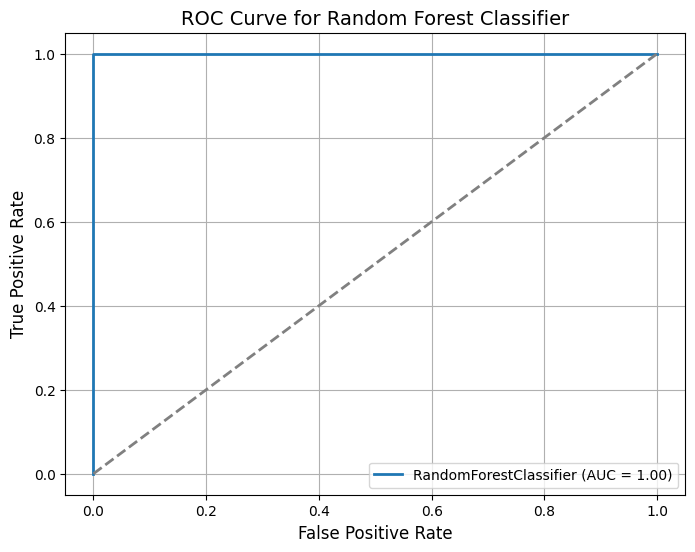

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.ensemble import RandomForestClassifier

# Assuming X_train, X_test, y_train, y_test are already defined

# Create and train the RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

# Get predictions and probabilities
y_pred = rfc.predict(X_test)
y_pred_prob = rfc.predict_proba(X_test)[:, 1] # Probability of positive class

# Calculate ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
plt.plot(fpr, tpr, lw=2, label=f'RandomForestClassifier (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--') # Diagonal line

# Set plot labels and title
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve for Random Forest Classifier', fontsize=14)
plt.legend(loc="lower right")

# Display the plot
plt.grid(True)
plt.savefig('/content/roc_curves.png')
plt.show()



In [ ]:
from sklearn.metrics import accuracy_score
knn=KNeighborsClassifier(n_neighbors=3)
svc=SVC(probability=True)
rfc=RandomForestClassifier()
abc=AdaBoostClassifier(learning_rate=5.0, random_state=1)
xgb=XGBClassifier()
gbc=GradientBoostingClassifier()
dtc=DecisionTreeClassifier()
gnb=GaussianNB()
models=[knn,svc,rfc,abc,xgb,gbc,dtc,gnb]
for model in models:
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  print('*'*50)
  print(model)
  print(accuracy_score(y_test,y_pred)*100)


**************************************************
KNeighborsClassifier(n_neighbors=3)
96.66666666666667
**************************************************
SVC(probability=True)
95.47619047619048
**************************************************
RandomForestClassifier()
97.61904761904762
**************************************************
AdaBoostClassifier(learning_rate=5.0, random_state=1)
72.61904761904762
**************************************************
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, m

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import json

classifiers = {
    "GradientBoostingClassifier": GradientBoostingClassifier(),
   "AdaBoostClassifier": AdaBoostClassifier(learning_rate=5.0, random_state=1),
    "XGBClassifier": XGBClassifier(),
    "KNeighborsClassifier": KNeighborsClassifier(n_neighbors=3),
    "RandomForestClassifier": RandomForestClassifier(),
    "SVC": SVC(probability=True),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "GaussianNB": GaussianNB()

}

# Dictionary to store metrics
metrics = {}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    metrics[name] = report

# Save metrics to JSON file
with open('classifiers_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

# Download the JSON file
from google.colab import files
files.download('classifiers_metrics.json')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

# Load the metrics from the JSON file
with open('classifiers_metrics.json', 'r') as f:
    metrics = json.load(f)

# Use the metrics as needed in your PyCharm project
print(metrics)


{'GradientBoostingClassifier': {'0': {'precision': 0.9714285714285714, 'recall': 0.9714285714285714, 'f1-score': 0.9714285714285714, 'support': 35.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 34.0}, '2': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 25.0}, '3': {'precision': 0.7647058823529411, 'recall': 0.9629629629629629, 'f1-score': 0.8524590163934426, 'support': 27.0}, '4': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 26.0}, '5': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 23.0}, '6': {'precision': 0.9365079365079365, 'recall': 0.9833333333333333, 'f1-score': 0.959349593495935, 'support': 60.0}, '7': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 32.0}, '8': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 26.0}, '9': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 34.0}, '10': {'precision': 1.0, 'recall': 0.8709677419354839, 'f1-score': 0.9310344827586207, 'suppor

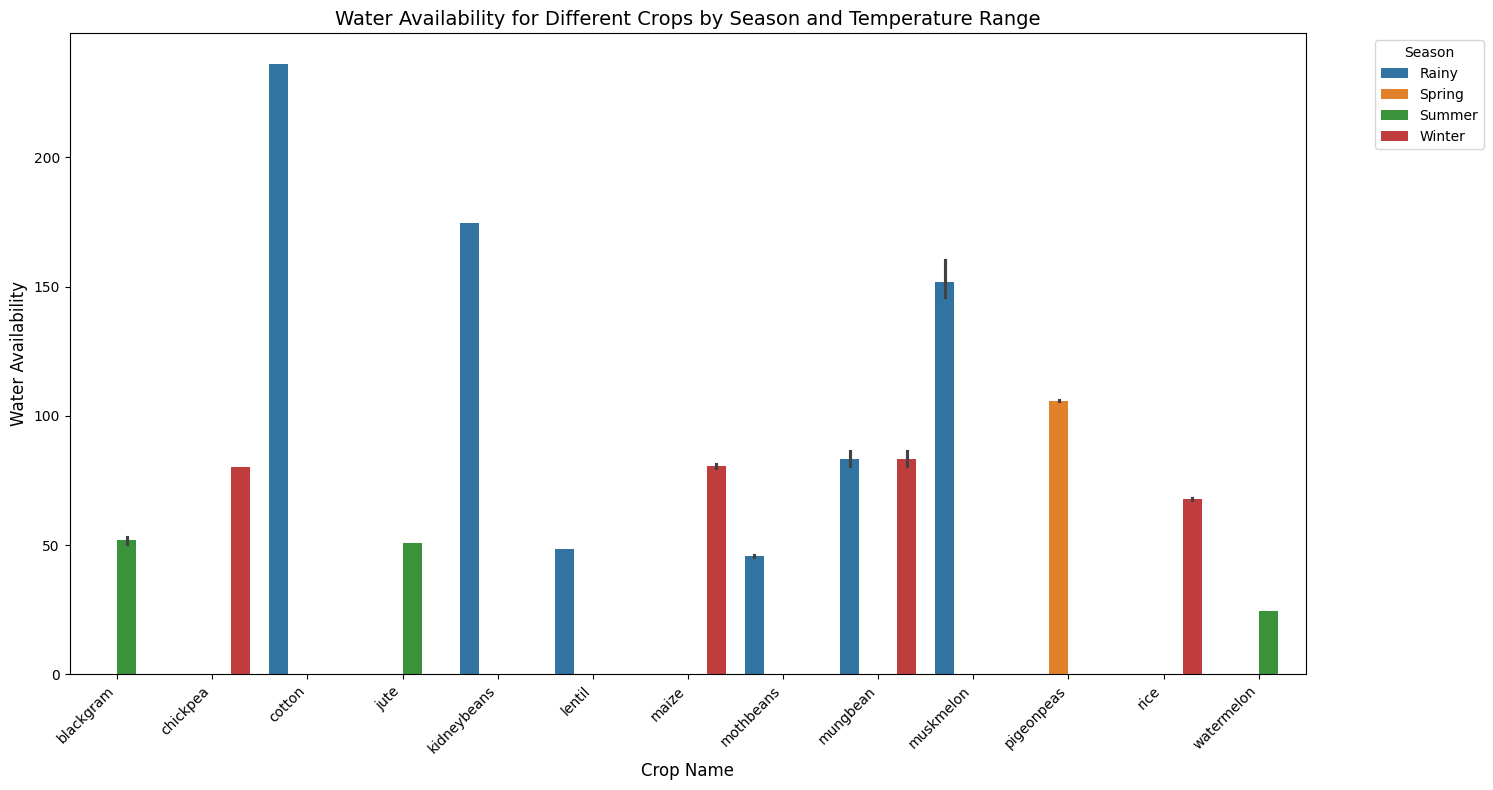

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
warnings.filterwarnings('ignore')

# 1. Extract unique crop names from the 'label' column of your DataFrame
labels = df['label'].unique() # Assuming 'label' column contains crop labels
labels=['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
    'mothbeans', 'mungbean', 'blackgram', 'lentil', 'watermelon',
    'muskmelon', 'cotton', 'jute']
label_mapping = {i: label for i, label in enumerate(labels)}

season_mapping = {
    0: 'Rainy',
    1: 'Spring',
    2: 'Summer',
    3: 'Winter'
}

# 2. Replace encoded values with actual names in new columns
df['crop_name'] = df['label'].map(label_mapping)
df['season_name'] = df['season'].map(season_mapping)

# 3. Create temperature ranges (optional - adjust ranges as needed)
df['temperature_range'] = pd.cut(df['temperature'], bins=[0, 10, 20, 30, 40],
                                 labels=['0-10', '10-20', '20-30', '30-40'])

# 4. Group data and calculate mean water availability
grouped_data = df.groupby(['crop_name', 'season_name', 'temperature_range'])['water availability'].mean().reset_index()

# 5. Create the grouped bar plot
plt.figure(figsize=(15, 8))
sns.barplot(x='crop_name', y='water availability', hue='season_name', data=grouped_data)

# 6. Customize plot elements
plt.xlabel("Crop Name", fontsize=12)
plt.ylabel("Water Availability", fontsize=12)
plt.title("Water Availability for Different Crops by Season and Temperature Range", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate x-axis labels if needed
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside

plt.tight_layout()
plt.show()
plt.savefig('/content/barplot.png', bbox_inches='tight')
plt.close()

In [ ]:
from google.colab import files
files.download('/content/barplot.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

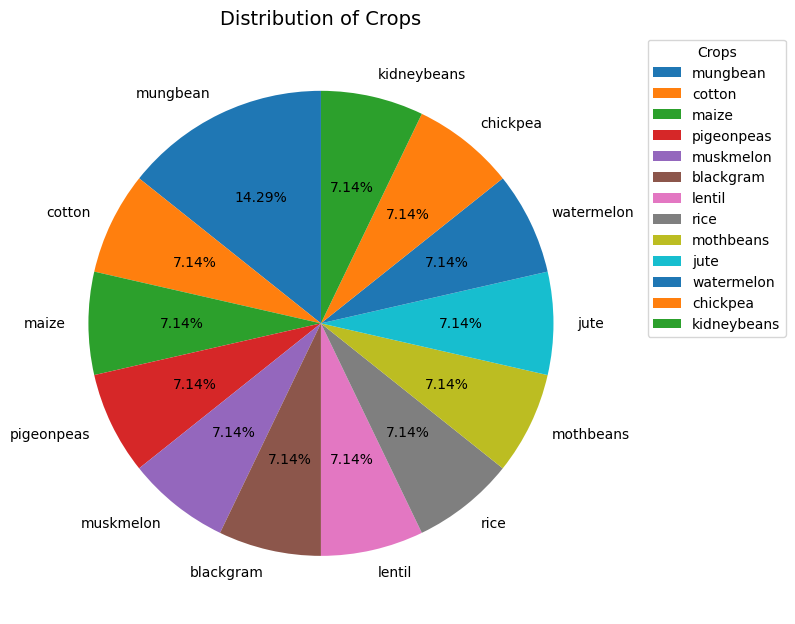

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# 1. Create a mapping dictionary for crop names
labels=['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
    'mothbeans', 'mungbean', 'blackgram', 'lentil', 'watermelon',
    'muskmelon', 'cotton', 'jute']
label_mapping = {i: label for i, label in enumerate(labels)} # Changed 'label' to 'labels'

# 2. Replace encoded values with actual crop names in a new column
df['crop_name'] = df['label'].map(label_mapping)

# 3. Get crop distribution using the 'crop_name' column
crop_counts = df['crop_name'].value_counts()

# 4. Create pie plot with actual crop names and their frequencies
plt.figure(figsize=(8, 8))
plt.pie(crop_counts.values, labels=crop_counts.index, autopct='%1.2f%%', startangle=90)


plt.title("Distribution of Crops", fontsize=14)
plt.legend(title='Crops', bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside
plt.tight_layout()
plt.show()

# SEASON VS CROPS

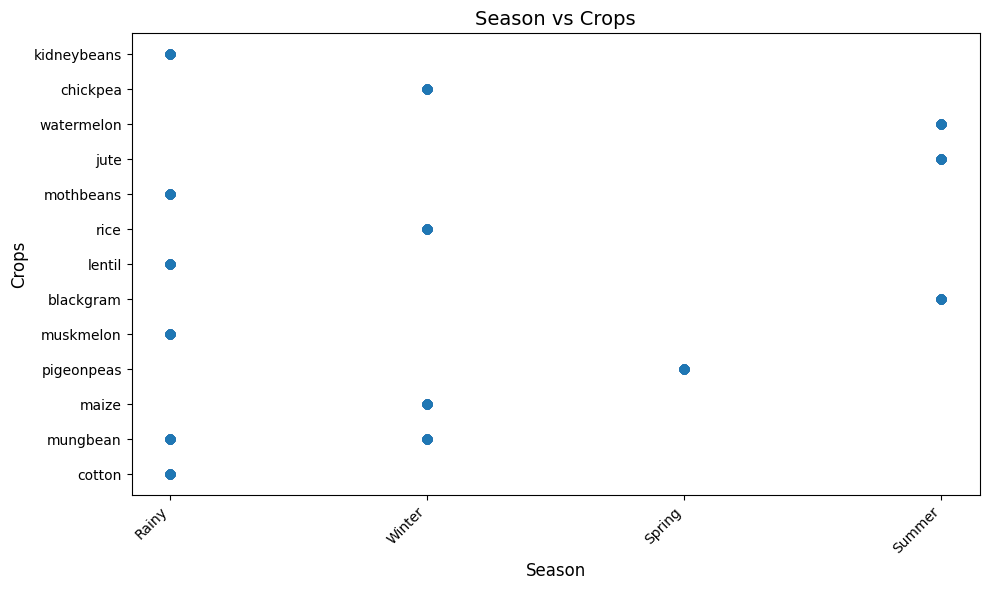

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Create mappings for season and label values
season_mapping = {
    0: 'Rainy',
    1: 'Spring',
    2: 'Summer',
    3: 'Winter'
}
label_mapping = {i: label for i, label in enumerate(labels)}

# new colm wth actual season and crop names
df['season_name'] = df['season'].map(season_mapping)
df['crop_name'] = df['label'].map(label_mapping)


plt.figure(figsize=(10, 6))
plt.scatter(df['season_name'], df['crop_name'])

plt.xlabel("Season", fontsize=12)
plt.ylabel("Crops", fontsize=12)
plt.title("Season vs Crops", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

plt.show()

# SEASON VS WATER AVAILABILITY

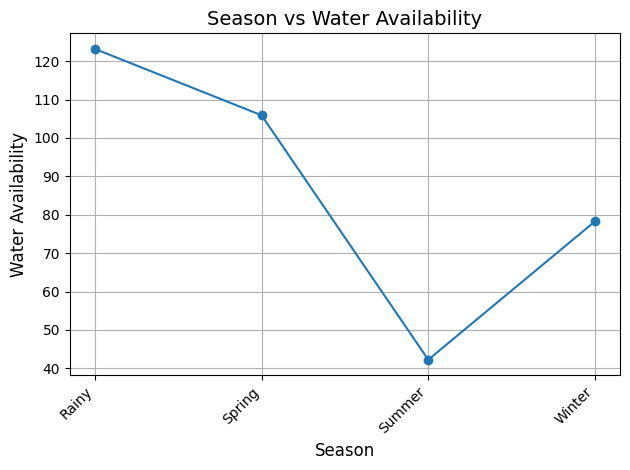

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Create a new DataFrame with season names and corresponding water availability values
season_water_data = df.groupby('season')['water availability'].mean().reset_index()

# Map encoded season values to actual season names
season_mapping = {
    0: 'Rainy',
    1: 'Spring',
    2: 'Summer',
    3: 'Winter'
}
season_water_data['season'] = season_water_data['season'].map(season_mapping)

plt.plot(season_water_data['season'], season_water_data['water availability'], 'o-')
plt.xlabel("Season", fontsize=12)
plt.ylabel("Water Availability", fontsize=12)
plt.title("Season vs Water Availability", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

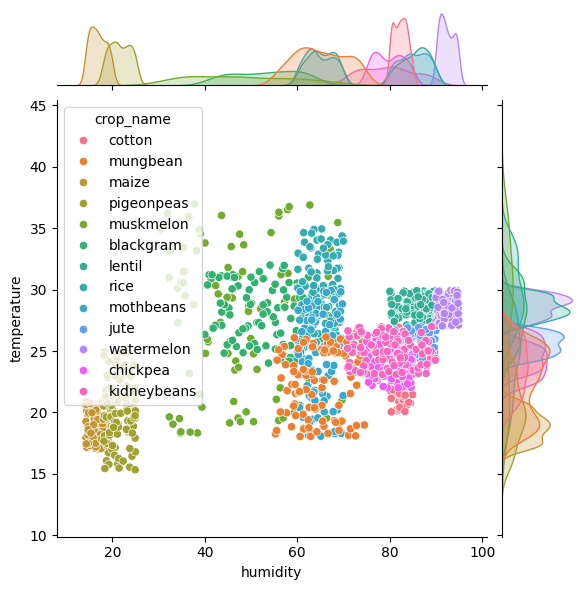

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Create a mapping dictionary
label_mapping = {i: label for i, label in enumerate(labels)}
# Replace encoded values with actual crop names in a new column
df['crop_name'] = df['label'].map(label_mapping)
sns.jointplot(x='humidity', y='temperature', data=df, hue='crop_name')
plt.show()

# TEMPERATURE VS CROPS

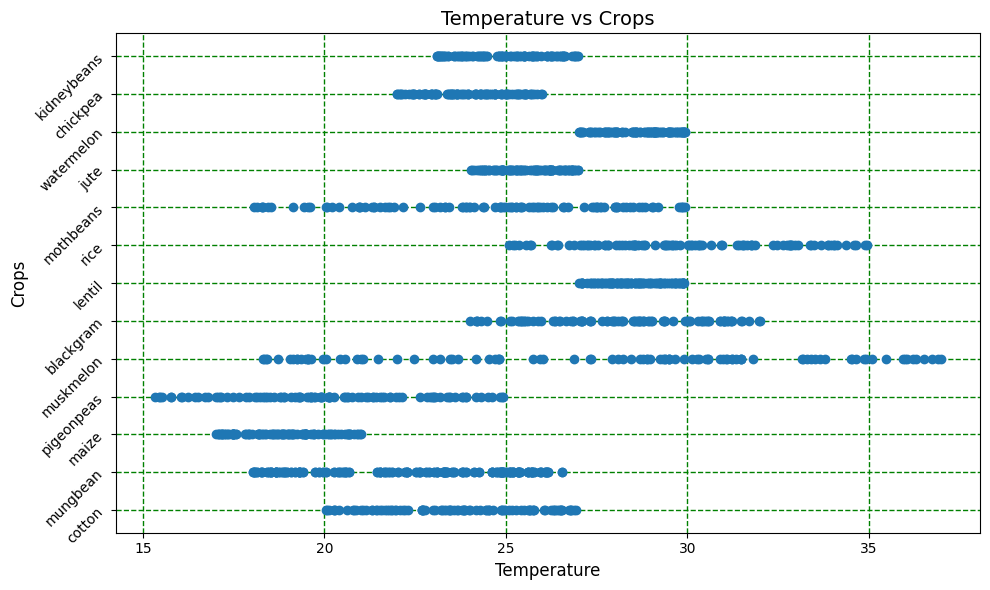

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Create a mapping dictionary
label_mapping = {i: label for i, label in enumerate(labels)}

# Replace encoded values with actual crop names in a new column
df['crop_name'] = df['label'].map(label_mapping)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(df['temperature'], df['crop_name'], 'o')  # Use 'o' for markers

plt.xlabel("Temperature", fontsize=12)
plt.ylabel("Crops", fontsize=12)
plt.title("Temperature vs Crops", fontsize=14)

# Customize grid
plt.grid(color='green', linestyle='--', linewidth=1)

# Rotate y-axis labels if needed
plt.yticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# HEAT MAP

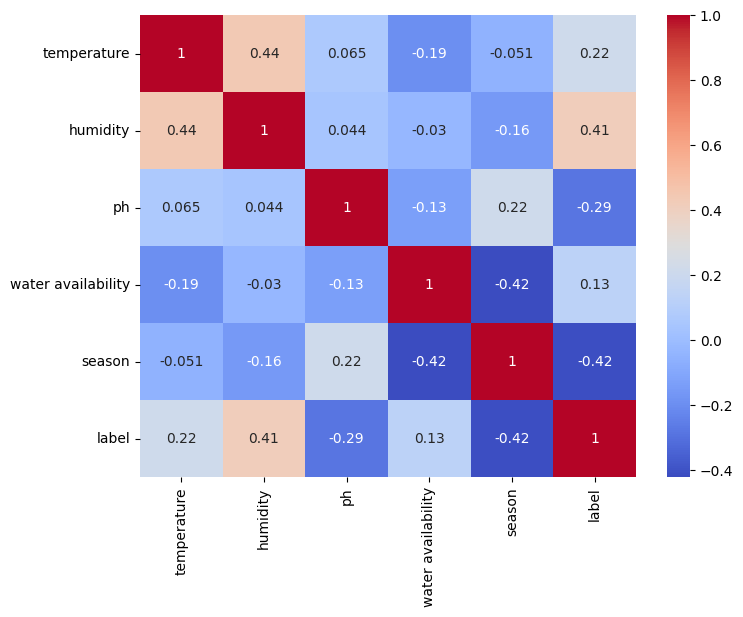

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'df' is your DataFrame
# Select only numerical features for correlation analysis
numerical_df = df.select_dtypes(include=np.number)  # This selects only columns with numerical data types

# Calculate the correlation matrix
corr = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.savefig("/content/correlation_heatmap.png")

In [ ]:
import pickle
pickle.dump(rfc,open('rfcccmodel.sav','wb'))

In [ ]:
pickle.dump(scaler,open('rfcccscaler.sav','wb'))